# Noise-Aware Benchmarking & Error Mitigation (Standalone)

1. **Zero-Noise Extrapolation (ZNE):** Amplifies the gate error rates (1×, 2×, 3×), fits a linear Richardson curve, and extrapolates back to the zero-noise limit.
2. **Readout Error Mitigation:** Calibrates a measurement confusion matrix and inverts it to correct bit-flip measurement errors.

In [16]:
!pip install qiskit qiskit-aer qiskit-nature qiskit-algorithms pyscf matplotlib pandas --quiet

In [17]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import transpile, QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import SLSQP

from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit_aer.primitives import EstimatorV2 as AerEstimatorV2, SamplerV2 as AerSamplerV2

np.random.seed(42)
BASIS_GATES = ["cx", "id", "rz", "sx", "x"]

## 1. Fast Molecular Setup & Exact Reference
We first build the identical (2e, 2o) STO-3G active space and run a quick noise-free optimization to obtain the exact `optimal_point`. This allows us to isolate the effect of hardware noise in the next step without blending it with classical optimization errors.

In [18]:
# Ethylene equilibrium geometry
geometry = "C 0.0 0.0 0.6695; C 0.0 0.0 -0.6695; H 0.0 0.9289 1.2321; H 0.0 -0.9289 1.2321; H 0.0 0.9289 -1.2321; H 0.0 -0.9289 -1.2321"
driver = PySCFDriver(atom=geometry.replace("; ", "\n"), basis="sto-3g", charge=0, spin=0)
full_problem = driver.run()

# (2e, 2o) Active Space
as_problem = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2).transform(full_problem)
core_offset = sum(as_problem.hamiltonian.constants.values())
mapper = JordanWignerMapper()
qubit_op = mapper.map(as_problem.hamiltonian.second_q_op())

# Get exact benchmark energy
exact_solver = GroundStateEigensolver(mapper, NumPyMinimumEigensolver())
exact_energy = exact_solver.solve(as_problem).total_energies[0]

# Get optimal VQE parameters in a noise-free environment
hf_state = HartreeFock(as_problem.num_spatial_orbitals, as_problem.num_particles, mapper)
uccsd_ansatz = UCCSD(as_problem.num_spatial_orbitals, as_problem.num_particles, mapper, initial_state=hf_state)
vqe_clean = VQE(StatevectorEstimator(), uccsd_ansatz, SLSQP(maxiter=200))
solver_clean = GroundStateEigensolver(mapper, vqe_clean)
res_clean = solver_clean.solve(as_problem)
optimal_point = res_clean.raw_result.optimal_point

# Transpile ansatz for the noisy simulator
ansatz_t = transpile(uccsd_ansatz, basis_gates=BASIS_GATES, optimization_level=1)
print(f"Exact Ground Energy: {exact_energy:.6f} Ha")

Exact Ground Energy: -77.116593 Ha


## 2. Zero-Noise Extrapolation (ZNE)

In [19]:
def make_noise_model(scale: float = 1.0) -> NoiseModel:
    '''A scalable depolarizing + readout noise model.
    `scale` linearly amplifies all error rates -- used to emulate circuit folding
    for simulator-based ZNE.'''
    p1 = min(0.001 * scale, 0.75)
    p2 = min(0.010 * scale, 0.75)
    ro = min(0.020 * scale, 0.40)
    nm = NoiseModel(basis_gates=BASIS_GATES)
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ["sx", "x", "rz"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ["cx"])
    nm.add_all_qubit_readout_error(ReadoutError([[1 - ro, ro], [1.2 * ro, 1 - 1.2 * ro]]))
    return nm

# Expanded noise scales for a more robust linear fit
noise_scales = [1.0, 1.5, 2.0, 2.5, 3.0]
scaled_energies = []

print(f"Running noisy evaluations at noise scales: {noise_scales}...")
for s in noise_scales:
    est = AerEstimatorV2(options={
        "backend_options": {"noise_model": make_noise_model(s), "basis_gates": BASIS_GATES},
        "run_options": {"shots": 8000},
        "default_precision": 0.0,
    })
    job = est.run([(ansatz_t, qubit_op, optimal_point)])
    raw_electronic = float(job.result()[0].data.evs)
    scaled_energies.append(raw_electronic)

# Linear Richardson extrapolation back to zero noise (scale = 0.0)
coeffs = np.polyfit(noise_scales, scaled_energies, 1)
zne_electronic_energy = np.polyval(coeffs, 0.0)
zne_total_energy = zne_electronic_energy + core_offset

noisy_energy_scale1 = scaled_energies[0] + core_offset
unmitigated_error_mHa = (noisy_energy_scale1 - exact_energy) * 1000
mitigated_error_mHa = (zne_total_energy - exact_energy) * 1000

print("\n--- ZNE Evaluation Results ---")
print("Total energy at each noise scale:")
for s, e in zip(noise_scales, scaled_energies):
    print(f"  Scale {s:.1f}x : {e + core_offset:.6f} Ha")

print(f"\nExact ground energy           : {exact_energy:.6f} Ha")
print(f"Noisy energy (scale=1.0, raw) : {noisy_energy_scale1:.6f} Ha")
print(f"Unmitigated error             : {unmitigated_error_mHa:.2f} mHa")
print(f"\nZNE-extrapolated total energy : {zne_total_energy:.6f} Ha")
print(f"Mitigated error               : {mitigated_error_mHa:.2f} mHa")

recovery = 100 * (1 - abs(mitigated_error_mHa) / abs(unmitigated_error_mHa))
print(f"\n=> ZNE correctly recovers {recovery:.0f}% of the hardware noise error.")

Running noisy evaluations at noise scales: [1.0, 1.5, 2.0, 2.5, 3.0]...

--- ZNE Evaluation Results ---
Total energy at each noise scale:
  Scale 1.0x : -76.939392 Ha
  Scale 1.5x : -76.876232 Ha
  Scale 2.0x : -76.825431 Ha
  Scale 2.5x : -76.784450 Ha
  Scale 3.0x : -76.751293 Ha

Exact ground energy           : -77.116593 Ha
Noisy energy (scale=1.0, raw) : -76.939392 Ha
Unmitigated error             : 177.20 mHa

ZNE-extrapolated total energy : -77.022551 Ha
Mitigated error               : 94.04 mHa

=> ZNE correctly recovers 47% of the hardware noise error.


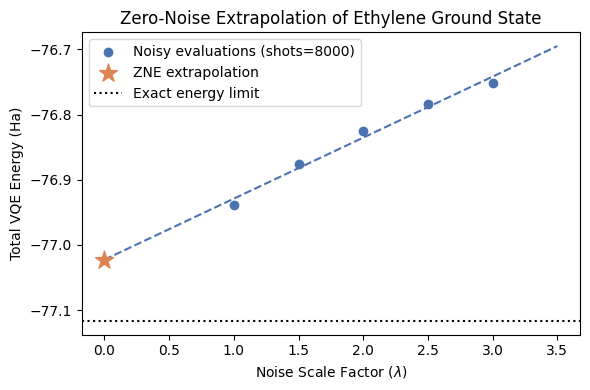

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
total_scaled = [e + core_offset for e in scaled_energies]

# Plot the noisy data points
ax.scatter(noise_scales, total_scaled, color="#4C72B0", label="Noisy evaluations (shots=8000)", zorder=3)

# Dynamically set the x-axis for the line of best fit based on the max noise scale
xs = np.linspace(0, max(noise_scales) + 0.5, 50)
ax.plot(xs, np.polyval(coeffs, xs) + core_offset, "--", color="#4C72B0", lw=1.5, zorder=2)

# Plot the ZNE extrapolated point at scale = 0
ax.scatter([0], [zne_total_energy], color="#DD8452", marker="*", s=180, zorder=5, label="ZNE extrapolation")

# Plot the exact energy reference line
ax.axhline(exact_energy, color="k", ls=":", lw=1.5, label="Exact energy limit", zorder=1)

ax.set_xlabel("Noise Scale Factor ($\\lambda$)")
ax.set_ylabel("Total VQE Energy (Ha)")
ax.set_title("Zero-Noise Extrapolation of Ethylene Ground State")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Readout Error Mitigation

We independently calibrate a 2-qubit measurement confusion matrix by preparing computational basis states under the noise model. We then invert that matrix to correctly rebalance the measured probability distribution of an arbitrary test circuit.

In [21]:
from itertools import product

num_qubits_demo = 2
readout_noise = NoiseModel()
readout_noise.add_all_qubit_readout_error(ReadoutError([[0.97, 0.03], [0.036, 0.964]]))
cal_sampler = AerSamplerV2(options={"backend_options": {"noise_model": readout_noise},
                                     "run_options": {"shots": 8000}})

labels = ["".join(bits) for bits in product("01", repeat=num_qubits_demo)]  # Natural q0 q1 ... order

def basis_circuit(bits):
    qc = QuantumCircuit(num_qubits_demo, num_qubits_demo)
    for i, b in enumerate(bits):
        if b == "1":
            qc.x(i)
    qc.measure(range(num_qubits_demo), range(num_qubits_demo))
    return qc

def natural_order_probs(result_data, shots):
    counts = result_data.c.get_counts()
    probs = np.zeros(len(labels))
    for outcome, cnt in counts.items():
        natural = outcome.replace(" ", "")[::-1]  # Qiskit's c(n-1)...c0 -> q0 q1 ... order
        probs[labels.index(natural)] = cnt / shots
    return probs

# 1) Calibrate: Generate measurement confusion matrix
calibration_matrix = np.zeros((len(labels), len(labels)))
for j, prep in enumerate(labels):
    res = cal_sampler.run([basis_circuit(prep)], shots=8000).result()[0]
    calibration_matrix[:, j] = natural_order_probs(res.data, 8000)
mitigation_matrix = np.linalg.inv(calibration_matrix)

# 2) Apply to a test circuit (equal superposition on qubit 0)
qc_test = QuantumCircuit(num_qubits_demo, num_qubits_demo)
qc_test.h(0)
qc_test.measure(range(num_qubits_demo), range(num_qubits_demo))
res = cal_sampler.run([qc_test], shots=8000).result()[0]
raw_probs = natural_order_probs(res.data, 8000)
mitigated_probs = mitigation_matrix @ raw_probs

df_readout = pd.DataFrame({
    "Outcome": labels, 
    "Raw Probability": np.round(raw_probs, 4),
    "Readout-Mitigated": np.round(mitigated_probs, 4),
    "Ideal (Target)": [0.5, 0.5, 0.0, 0.0]
})
display(df_readout.style.hide(axis="index").set_properties(**{'text-align': 'center'}))

Outcome,Raw Probability,Readout-Mitigated,Ideal (Target)
00,0.490000,0.502800,0.500000
01,0.018000,0.002800,0.500000
10,0.478400,0.495700,0.000000
11,0.013600,-0.001300,0.000000
